In [1]:
import numpy as np
import matplotlib.pyplot as plt
from codes.Quantum import *
from codes.CSPSA import *

In [2]:
psi = np.array([1, 0 , 0 , 1])/np.sqrt(2)
rho = np.outer( psi, psi.conj() )
rho 

array([[0.5, 0. , 0. , 0.5],
       [0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. ],
       [0.5, 0. , 0. , 0.5]])

In [3]:
def vector2observable( z ):
    return np.eye(2) - 2*np.outer( z,z.conj() )

In [4]:
def postprocessing( x ):
    x = x/np.linalg.norm(x, axis=0 )
    return x 

def obj_fun( x, rho ):

    x = postprocessing( x )

    x0 = x[:,0]
    O0 = vector2observable( x0 )
    x1 = x[:,1]
    O1 = vector2observable( x1 )
    x2 = x[:,2]
    O2 = vector2observable( x2 )
    x3 = x[:,3]
    O3 = vector2observable( x3 )

    Bell = ( np.trace( rho@np.kron(O0,O2) ) 
            + np.trace( rho@np.kron(O0,O3) ) 
            + np.trace( rho@np.kron(O1,O2) ) 
            - np.trace( rho@np.kron(O1,O3) ) )
    
    return Bell 

In [5]:
gains = [ 0.2, 0, 0.2, 0.602, 0.101]
cspsa = CSPSA(gains=gains, minimize=False )
max_iter = 100

z_in = np.array( [ RandomState(2), 
                  RandomState(2), 
                  RandomState(2), 
                  RandomState(2) ] ).T
z_in 

array([[ 0.62956162+0.54679016j,  0.0481091 +0.07713418j,
         0.10135574-0.32778562j,  0.0385555 +0.29370749j],
       [-0.40751314-0.37229789j, -0.70063638+0.70770368j,
         0.92208328-0.17901404j, -0.55210466+0.77937785j]])

In [20]:
results = cspsa.minimize( obj_fun, 
                         z_in, 
                         max_iter, 
                         postprocessing=postprocessing,
                         args = (rho) )

c:\Users\lucia\miniconda3\lib\site-packages\matplotlib\cbook\__init__.py:1335: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(2.8280702530518584+0j)

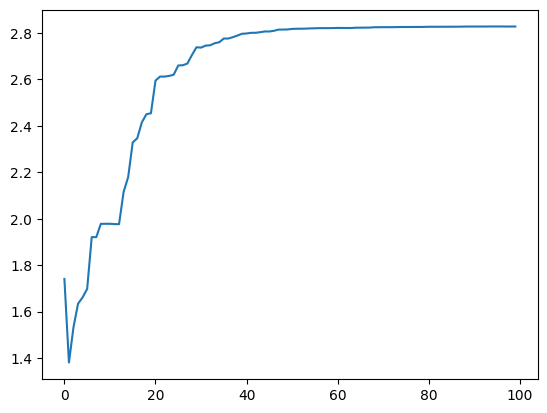

In [21]:
bell = results.fun
plt.plot( bell )
bell[-1]